# (01) GaBe: KL plot

**Motivation**: host = ```any```, device = ```cuda:0``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

In [3]:
def spike_prob(mu, sigma):
    """Compute spike probability: Φ(μ/√(1 + σ²))"""
    return sp_stats.norm.cdf(mu / np.sqrt(1 + sigma**2))

def kl_bernoulli(q, p):
    """KL divergence between two Bernoulli distributions"""
    eps = 1e-10  # Avoid log(0)
    q = np.clip(q, eps, 1 - eps)
    p = np.clip(p, eps, 1 - eps)
    term1 = q * np.log(q / p)
    term2 = (1 - q) * np.log((1 - q) / (1 - p))
    return term1 + term2

## Make plots

### Case 1: sigma fixed

In [4]:
# Parameters
mu_range = (-3, 3)
resolution = 100
sigma = 1  # Fixed sigma = 1

# Create mesh
mu_values = np.linspace(mu_range[0], mu_range[1], resolution)
prior_mu, posterior_mu = np.meshgrid(mu_values, mu_values)

# Compute spike probabilities
prior_spike_prob = spike_prob(prior_mu, sigma)
posterior_spike_prob = spike_prob(posterior_mu, sigma)

# Compute KL divergence
kl_matrix_sigma_fixed = kl_bernoulli(posterior_spike_prob, prior_spike_prob)

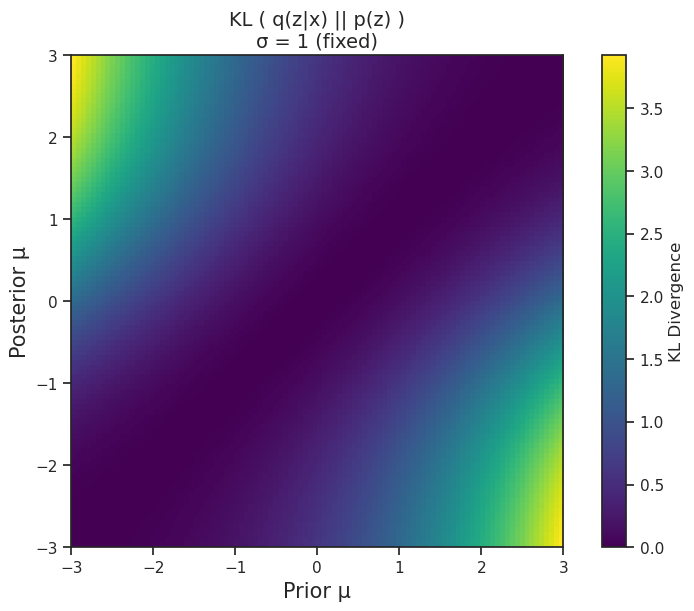

In [5]:
# Create heatmap
fig, ax = create_figure(figsize=(8, 6))
extent = [mu_range[0], mu_range[1], mu_range[0], mu_range[1]]
im = plt.imshow(kl_matrix_sigma_fixed, extent=extent, 
                origin='lower', cmap='viridis', aspect='equal')
plt.colorbar(im, ax=ax, label='KL Divergence')
ax.set_xlabel('Prior μ', fontsize=15)
ax.set_ylabel('Posterior μ', fontsize=15)
ax.set_title('KL ( q(z|x) || p(z) )\nσ = 1 (fixed)', fontsize=14)
ax_square(ax)
plt.show()

### Case 2: mu fixed

In [6]:
# Parameters
log_sigma_range = (-3, 3)
resolution = 100
mu = 1  # Fixed sigma = 1

# Create mesh
log_sigma_values = np.linspace(log_sigma_range[0], log_sigma_range[1], resolution)
prior_log_sigma, posterior_log_sigma = np.meshgrid(log_sigma_values, log_sigma_values)

# Compute spike probabilities
prior_spike_prob = spike_prob(mu, np.exp(prior_log_sigma))
posterior_spike_prob = spike_prob(mu, np.exp(posterior_log_sigma))

# Compute KL divergence
kl_matrix_mu_fixed = kl_bernoulli(posterior_spike_prob, prior_spike_prob)

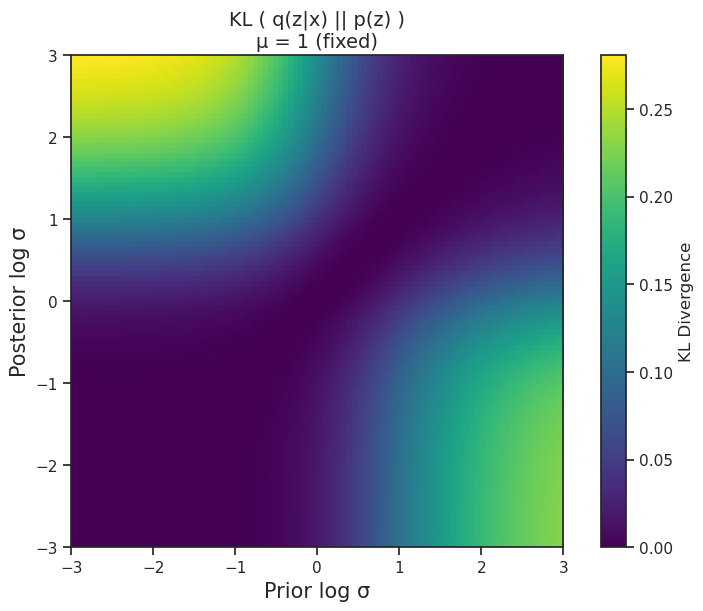

In [7]:
# Create heatmap
fig, ax = create_figure(figsize=(8, 6))
extent = [log_sigma_range[0], log_sigma_range[1], log_sigma_range[0], log_sigma_range[1]]
im = plt.imshow(kl_matrix_mu_fixed, extent=extent, 
                origin='lower', cmap='viridis', aspect='equal')
plt.colorbar(im, ax=ax, label='KL Divergence')
ax.set_xlabel('Prior log σ', fontsize=15)
ax.set_ylabel('Posterior log σ', fontsize=15)
ax.set_title('KL ( q(z|x) || p(z) )\nμ = 1 (fixed)', fontsize=14)
ax_square(ax)
plt.show()

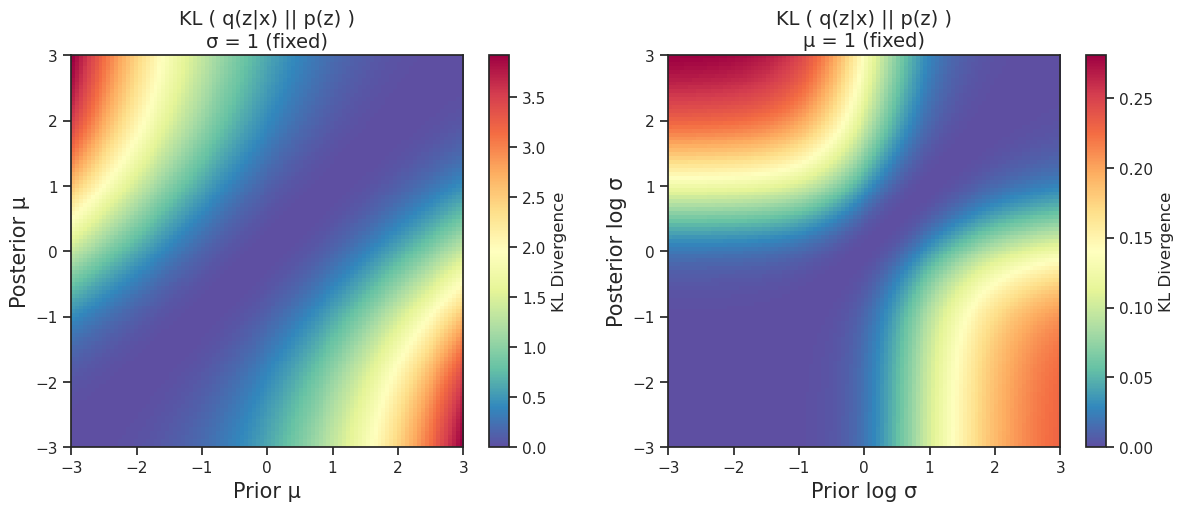

In [8]:
fig, axes = create_figure(1, 2, figsize=(12, 5))

cmap = 'Spectral_r'

ax = axes[0]
extent = [mu_range[0], mu_range[1], mu_range[0], mu_range[1]]
im = ax.imshow(kl_matrix_sigma_fixed, extent=extent,
               origin='lower', cmap=cmap, aspect='equal')
plt.colorbar(im, ax=ax, label='KL Divergence')
ax.set_xlabel('Prior μ', fontsize=15)
ax.set_ylabel('Posterior μ', fontsize=15)
ax.set_title('KL ( q(z|x) || p(z) )\nσ = 1 (fixed)', fontsize=14)

ax = axes[1]
extent = [log_sigma_range[0], log_sigma_range[1], log_sigma_range[0], log_sigma_range[1]]
im = ax.imshow(kl_matrix_mu_fixed, extent=extent,
               origin='lower', cmap=cmap, aspect='equal')
plt.colorbar(im, ax=ax, label='KL Divergence')
ax.set_xlabel('Prior log σ', fontsize=15)
ax.set_ylabel('Posterior log σ', fontsize=15)
ax.set_title('KL ( q(z|x) || p(z) )\nμ = 1 (fixed)', fontsize=14)
ax_square(ax)

fig.savefig

plt.show()

In [9]:
save_fig('GaBe_KL.pdf', fig_base_dir, fig)

'/home/hadi/Dropbox/git/jb-progress-2025/figs/GaBe_KL.pdf'